In [2]:
#导包
import torch
import torch.nn as nn
from torchvision.datasets import MNIST #MNIST数据集
from torchvision.transforms import ToTensor #数据预处理,将图片转换为张量
import torch.optim as optim #优化器，用于更新模型参数
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader #数据加载器，用于批量加载数据
import time
from torchsummary import summary





d:\Anaconda_envs\envs\aitest01\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] 找不到指定的程序。'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [49]:
#dataset和dataloader
#dataset：数据集，用于存储样本和标签
#dataloader：数据加载器，用于批量加载数据

#api
#torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False, sampler=None, batch_sampler=None, num_workers=0, collate_fn=None, pin_memory=False, drop_last=False, timeout=0, worker_init_fn=None, *, prefetch_factor=2, persistent_workers=False)
#参数：
#dataset：数据集，用于存储样本和标签
#batch_size：批量大小，默认值为1
#shuffle：是否随机打乱数据集，默认值为False
#sampler：采样器，用于自定义样本采样策略，默认值为None
#batch_sampler：批量采样器，用于自定义批量采样策略，默认值为None
#num_workers：加载数据的子进程数，默认值为0
#collate_fn：合并样本的函数，默认值为None
#pin_memory：是否将数据.pin_memory()，默认值为False
#drop_last：是否丢弃最后一个不完整的批量，默认值为False
#timeout：数据加载超时时间，默认值为0
#worker_init_fn：子进程初始化函数，默认值为None

#torch.utils.data.TensorDataset(data_tensor, target_tensor)
#参数：
#data_tensor：样本张量,
# 第一个维度表示样本数量,
# 第二个维度表示特征维度。
#target_tensor：标签张量,
# 第一个维度表示样本数量,
# 第二个维度表示标签维度。



torch.Size([60000, 28, 28])
torch.Size([10000, 28, 28])
{'0 - zero': 0, '1 - one': 1, '2 - two': 2, '3 - three': 3, '4 - four': 4, '5 - five': 5, '6 - six': 6, '7 - seven': 7, '8 - eight': 8, '9 - nine': 9}


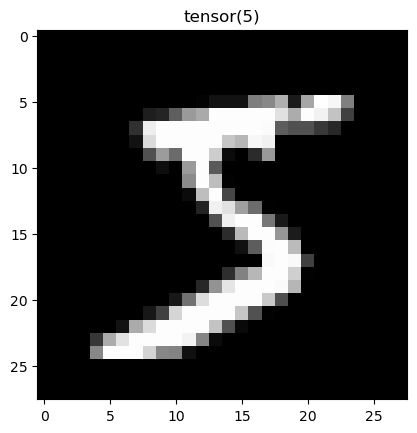

In [3]:
#加载MNIST数据集
train_dataset=MNIST(root='./data',train=True,transform=ToTensor(),download=True) #训练集,参数：root：数据集存储路径,train：是否为训练集,transform：数据预处理,download：是否下载数据集
test_dataset=MNIST(root='./data',train=False,transform=ToTensor(),download=True) #测试集
print(train_dataset.data.shape)
print(test_dataset.data.shape)
print(test_dataset.class_to_idx)

plt.imshow(train_dataset.data[0],cmap='gray')
plt.title(train_dataset.targets[0])
plt.show()

In [4]:
#搭建模型
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
class cnn1(nn.Module):
    def __init__(self):
        super().__init__()
        self.cnn1=nn.Conv2d(in_channels=1,out_channels=6,kernel_size=3,stride=1,padding=1) #特征图大小28
        self.bn1=nn.BatchNorm2d(6)
        self.pool1=nn.MaxPool2d(kernel_size=2,stride=2) #特征图大小14
        self.cnn2=nn.Conv2d(in_channels=6,out_channels=16,kernel_size=3,stride=1) #特征图大小12
        self.bn2=nn.BatchNorm2d(16)
        self.pool2=nn.MaxPool2d(kernel_size=2,stride=1) #特征图大小11
        self.fc1=nn.Linear(1936,120)

        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,32)
        self.fc4=nn.Linear(32,10)
    def forward(self,x):
        x=self.cnn1(x)
        x=self.bn1(x)
        x=torch.relu(x)
        x=self.pool1(x)
        x=self.cnn2(x)
        x=self.bn2(x)
        x=torch.relu(x)
        x=self.pool2(x)
        x=x.reshape(x.shape[0],-1) #将特征图展平,第一个维度表示样本数量,第二个维度表示特征图的高度和宽度（由于池化层减少了空间维度,所以高度和宽度会减半）
        x=self.fc1(x)
        x=torch.relu(x)
        x=self.fc2(x)
        x=torch.relu(x)
        x=self.fc3(x)
        x=torch.tanh(x)
        x=self.fc4(x)
        return x


In [5]:
class cnn2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, stride=1, padding=1),  # 特征图大小28
            nn.BatchNorm2d(num_features=6),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 特征图大小14

            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=3, stride=1),  # 特征图大小12
            nn.BatchNorm2d(num_features=16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=1),  # 特征图大小11

            nn.Flatten(),
            nn.Linear(1936, 120),
            nn.ReLU(),

            nn.Linear(120, 84),
            nn.ReLU(),

            nn.Linear(84, 32),
            nn.Tanh(),

            nn.Linear(32, 10)
        )
    def forward(self,x):
        return self.model(x)

            

In [6]:
# 训练模型

model1=cnn1()
criterion=nn.CrossEntropyLoss() #交叉熵损失函数
optim=optim.Adam(model1.parameters(),lr=0.001) #adam优化器
epoch=20 #训练轮数
for epoch in range(epoch):
    model1.train()
    total_loss,total_samples,total_correct,start_time=0,0,0,time.time()
    for data,target in train_loader:
        optim.zero_grad()
        output=model1(data)
        loss=criterion(output,target)
        loss.backward()
        optim.step()
        total_loss+=loss.item()*data.size(0) #一批的平均损失乘以样本数
        total_samples+=data.shape[0] #一批的样本数
        total_correct+=(torch.argmax(output,dim=1)==target).sum() #一批的正确预测数
       
    time_end=time.time()
    print(f"epoch:{epoch},loss:{total_loss/total_samples:.4f},accuracy:{total_correct/total_samples:.4f},time:{time_end-start_time:.4f}")



epoch:0,loss:0.1773,accuracy:0.9556,time:16.2494
epoch:1,loss:0.0637,accuracy:0.9821,time:16.7823
epoch:2,loss:0.0482,accuracy:0.9856,time:16.8903
epoch:3,loss:0.0391,accuracy:0.9890,time:17.4795
epoch:4,loss:0.0329,accuracy:0.9903,time:17.7831
epoch:5,loss:0.0312,accuracy:0.9912,time:17.9660
epoch:6,loss:0.0256,accuracy:0.9929,time:17.1172
epoch:7,loss:0.0214,accuracy:0.9938,time:17.2294
epoch:8,loss:0.0208,accuracy:0.9939,time:17.1897
epoch:9,loss:0.0168,accuracy:0.9949,time:17.8521
epoch:10,loss:0.0173,accuracy:0.9946,time:17.0483
epoch:11,loss:0.0153,accuracy:0.9954,time:17.4156
epoch:12,loss:0.0157,accuracy:0.9955,time:17.8558
epoch:13,loss:0.0144,accuracy:0.9958,time:17.7952
epoch:14,loss:0.0131,accuracy:0.9964,time:18.3002
epoch:15,loss:0.0130,accuracy:0.9964,time:18.7921
epoch:16,loss:0.0108,accuracy:0.9967,time:19.0157
epoch:17,loss:0.0102,accuracy:0.9970,time:17.4808
epoch:18,loss:0.0100,accuracy:0.9973,time:17.7083
epoch:19,loss:0.0109,accuracy:0.9969,time:18.3211


In [9]:
model2=cnn2()
epochs=20
optimizer=torch.optim.Adam(model2.parameters(),lr=0.001)
criterion=nn.CrossEntropyLoss()
for epoch in range(epochs):
    model2.train()
    total_loss,total_samples,total_correct,start_time=0,0,0,time.time()
    for data,target in train_loader:
        optimizer.zero_grad()
        output=model2(data)
        loss=criterion(output,target)   
        loss.backward()
        optimizer.step()
        total_loss+=loss.item()*data.size(0) #一批的平均损失乘以样本数
        total_samples+=data.shape[0] #一批的样本数
        total_correct+=(torch.argmax(output,dim=1)==target).sum() #一批的正确预测数
       
    time_end=time.time()
    print(f"epoch:{epoch},loss:{total_loss/total_samples:.4f},accuracy:{total_correct/total_samples:.4f},time:{time_end-start_time:.4f}")



epoch:0,loss:0.1760,accuracy:0.9539,time:16.1760
epoch:1,loss:0.0619,accuracy:0.9825,time:16.6352
epoch:2,loss:0.0460,accuracy:0.9866,time:17.0061
epoch:3,loss:0.0398,accuracy:0.9884,time:16.8926
epoch:4,loss:0.0325,accuracy:0.9905,time:17.1010
epoch:5,loss:0.0290,accuracy:0.9913,time:16.6462
epoch:6,loss:0.0246,accuracy:0.9928,time:17.9979
epoch:7,loss:0.0218,accuracy:0.9938,time:17.2411
epoch:8,loss:0.0206,accuracy:0.9940,time:16.8813
epoch:9,loss:0.0203,accuracy:0.9941,time:16.7771
epoch:10,loss:0.0154,accuracy:0.9954,time:17.1381
epoch:11,loss:0.0134,accuracy:0.9961,time:15.8511
epoch:12,loss:0.0145,accuracy:0.9954,time:15.9510
epoch:13,loss:0.0137,accuracy:0.9957,time:16.7009
epoch:14,loss:0.0109,accuracy:0.9966,time:17.6302
epoch:15,loss:0.0112,accuracy:0.9968,time:16.4518
epoch:16,loss:0.0108,accuracy:0.9970,time:16.7103
epoch:17,loss:0.0081,accuracy:0.9974,time:17.7533
epoch:18,loss:0.0115,accuracy:0.9966,time:16.7768
epoch:19,loss:0.0084,accuracy:0.9975,time:17.3973


In [ ]:
#保存模型
torch.save(model1.state_dict(),'model.pth')

In [ ]:
#模型测试
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=True)
#创建模型对象
model=cnn1()
#加载模型参数
model.load_state_dict(torch.load('model.pth'))
#将模型设置为评估模式
model.eval()
#测试
total_loss,total_correct,total_samples=0,0,0
for x,y in test_loader:
    y_pred=model(x)
    loss=criterion(y_pred,y)
    total_loss+=loss.item()*x.shape[0]
    total_samples+=x.shape[0]
    total_correct+=(torch.argmax(y_pred,dim=1)==y).sum()
total_accuracy=total_correct/total_samples
print(f"test loss:{total_loss/total_samples:.4f},test accuracy:{total_accuracy:.4f}")


test loss:0.0853,test accuracy:0.9815


torch.Size([16, 1, 28, 28])


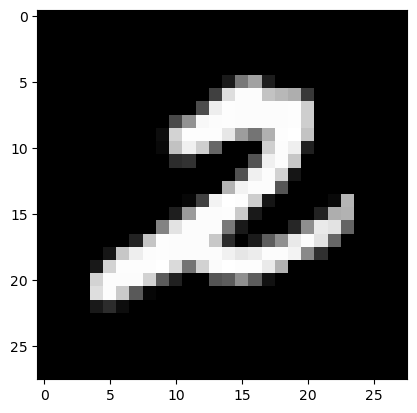

tensor(2)


In [ ]:
#优化方向
#1.增加训练轮数
#2.调整学习率
#3.使用其他优化器
#4.添加正则化项
#5.增加模型复杂度

print(x.shape)
plt.imshow(x[1].permute(1,2,0).numpy(),cmap='gray')
plt.show()
print(torch.argmax(y_pred[1]))